In [127]:
import matplotlib.pyplot as plt
import os
import torch
import matplotlib.pyplot as plt
import networkx as nx
import math


In [128]:

dicio = {
    "AdaptableSnail":{
        'num_mice': 4,
        'num_parts': 18,
        'num_nodes': 72,
        'num_classes': 7,
        'action_names': ['approach', 'attack', 'avoid', 'chase', 'chaseattack', 'rear', 'submit'],
        'bodyparts': [
            'body_center', 'ear_left', 'ear_right', 'lateral_left', 'lateral_right', 
            'nose', 'tail_base', 'tail_midpoint', 'tail_tip', 'neck', 
            'headpiece_bottombackleft', 'headpiece_bottombackright', 
            'headpiece_topbackleft', 'headpiece_topbackright', 
            'headpiece_topfrontleft', 'headpiece_topfrontright', 
            'headpiece_bottomfrontleft', 'headpiece_bottomfrontright'
        ],
        'skeleton_edges': [(5, 9),(1, 9),(2, 9),(9, 0),(0, 3),(0, 4),(0, 6),(6, 7),(7, 8),(9, 10), (9, 11),(10, 12), (11, 13), (12, 14), (13, 15), (14, 16), (15, 17)]
    },
    "CalMS21_supplemental": {
        'num_mice': 2,
        'num_parts': 7,
        'num_nodes': 14,
        'num_classes': 10,
        'action_names': ['approach', 'attack', 'attemptmount', 'dominancemount', 'intromit', 'mount', 'sniff', 'sniffbody', 'sniffface', 'sniffgenital'],
        'bodyparts': ['ear_left', 'ear_right', 'hip_left', 'hip_right', 'neck', 'nose', 'tail_base'],
        'skeleton_edges': [(5, 4), (0, 4), (1, 4), (4, 6), (2, 6), (3, 6)]
    },
    "CRIM13": {
        'num_mice': 2,
        'num_parts': 7,
        'num_nodes': 14,
        'num_classes': 7,
        'action_names': ['approach', 'attack', 'disengage', 'mount', 'rear', 'selfgroom', 'sniff'],
        'bodyparts': ['ear_left', 'ear_right', 'hip_left', 'hip_right', 'neck', 'nose', 'tail_base'],
        'skeleton_edges': [(5, 4), (0, 4), (1, 4), (4, 6), (2, 6), (3, 6)]
    },
    "BoisterousParrot": {
        'num_mice': 2,
        'num_parts': 5,
        'num_nodes': 10,
        'num_classes': 1,
        'action_names': ['shepherd'],
        'bodyparts': ['body_center', 'ear_left', 'ear_right', 'nose', 'tail_base'],
        'skeleton_edges': [(3, 0), (1, 0), (2, 0), (4, 0)]
    }
}


In [129]:
device = torch.device("cpu")

In [ ]:
def show_plot_metrics(model, config):

    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.title("Train losses")
    plt.plot(model["train_losses"])
    plt.xlabel("Epochs")
    
    plt.subplot(1,2,2)
    plt.title("Test Accuracy")
    plt.plot(model["val_accs"], color="#34A300")
    plt.xlabel("Epochs")

    plt.suptitle(model["name"])

    plt.show()

    plt.figure(figsize=(8,8))
    G = nx.Graph()
    

    # Adicionar nós (Bodyparts)
    # Usamos o índice como ID e o nome como label
    for idx, part_name in enumerate(config['bodyparts']):
        G.add_node(idx, label=part_name)
        
    # Adicionar arestas (Skeleton Edges)
    G.add_edges_from(config['skeleton_edges'])
    
    # 2. Definir Layout (Posição Visual)
    # spring_layout tenta separar os nós de forma orgânica
    pos = nx.spring_layout(G, seed=42, k=0.5) 
    
    # 3. Desenhar
    # Desenha os nós
    nx.draw_networkx_nodes(G, pos, node_size=700, node_color='skyblue', edgecolors='black')
    
    nx.draw_networkx_edges(G, pos, width=2, edge_color='gray')

    if G.number_of_nodes() < 10:
        # Desenha as arestas
        labels = nx.get_node_attributes(G, 'label')
        text_pos = {k: (v[0], v[1]+0.15) for k, v in pos.items()}
        nx.draw_networkx_labels(G, text_pos, labels=labels, font_size=15, font_weight='bold')
    plt.axis(False)
    plt.show()


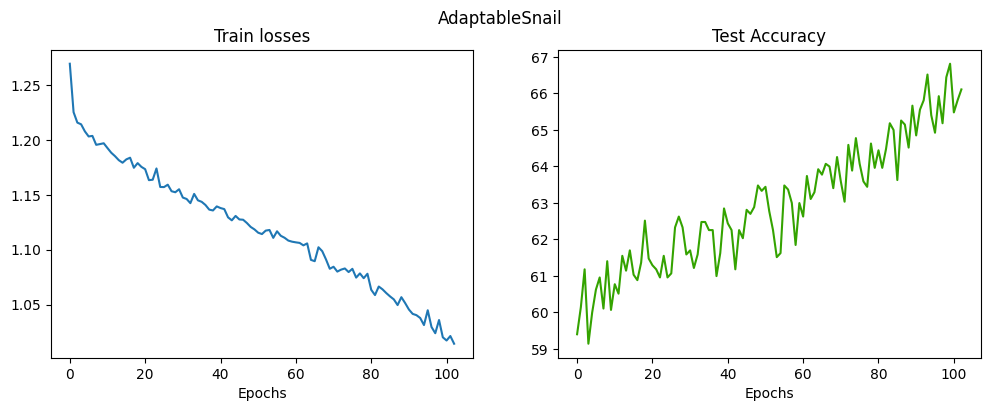

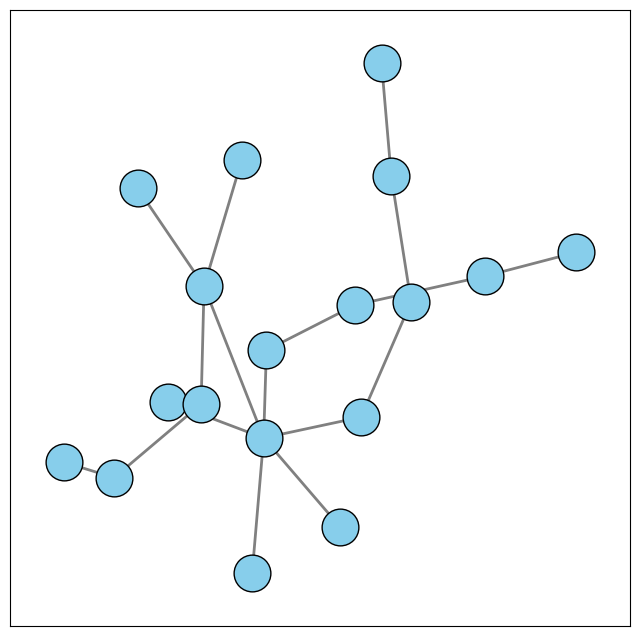

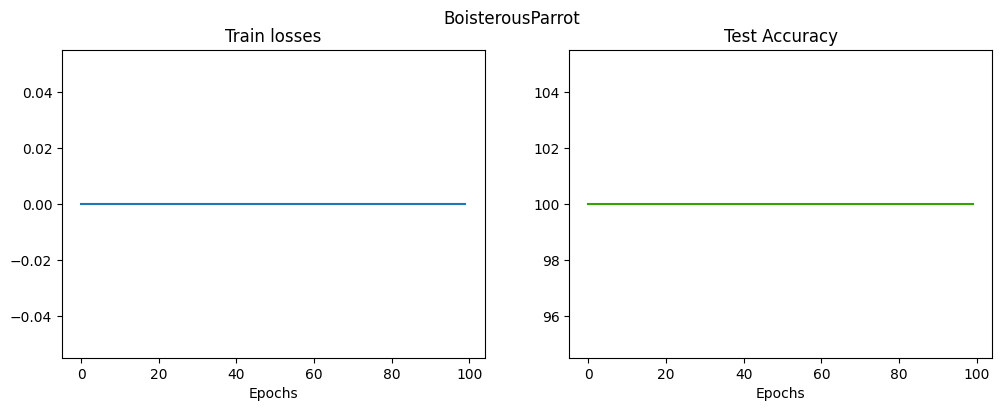

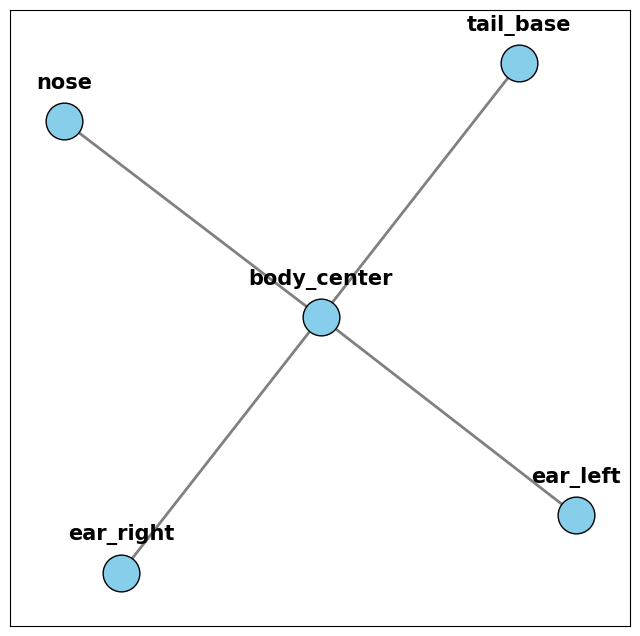

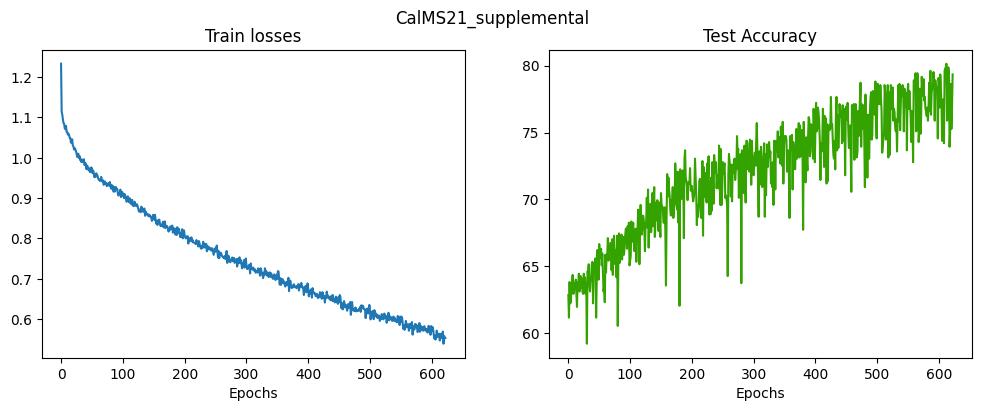

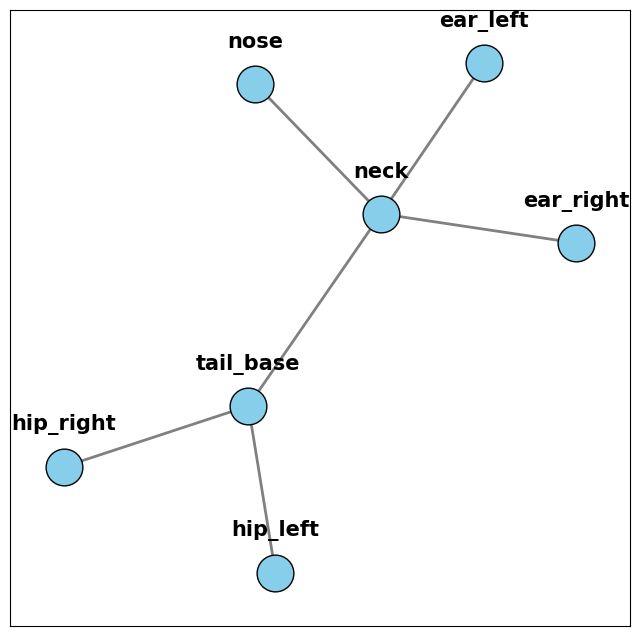

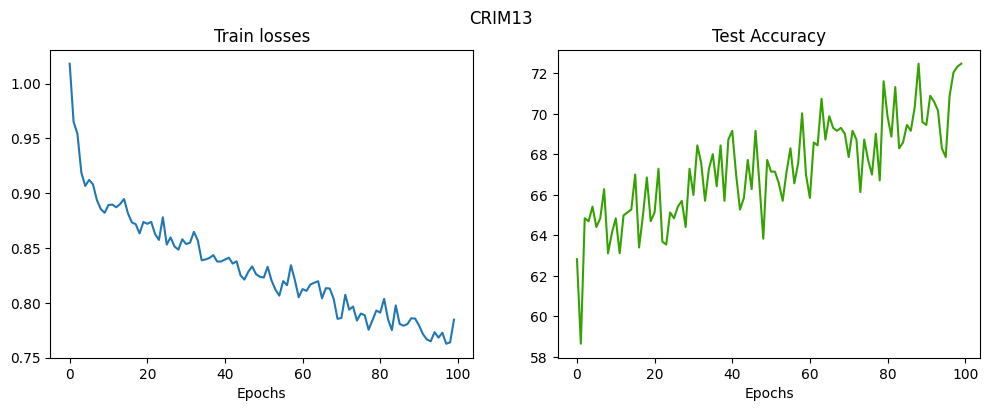

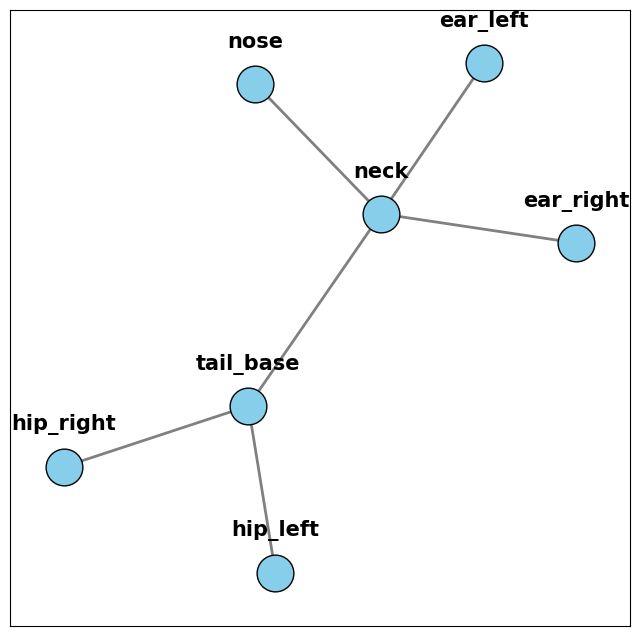

In [131]:

for model_path in os.listdir("modelos"):
    checkpoint = torch.load(fr"modelos/{model_path}", map_location=device)
    checkpoint['name'] = model_path[15: -4]
    show_plot_metrics(checkpoint, dicio[checkpoint['name']])
    